In [1]:
from google.colab import files as colab_files
import os, json

for fname in ["train.json", "val.json", "test.json"]:
    for suffix in ["", " (1)", " (2)", " (3)"]:
        path = f"/content/{fname.replace('.json', suffix + '.json')}"
        if os.path.exists(path):
            os.remove(path)

print("Upload train.json, val.json, test.json from vigenere/ folder")
uploaded = colab_files.upload()

for fname in ["train.json", "val.json", "test.json"]:
    match = next((k for k in uploaded if fname.replace(".json","") in k), None)
    if match is None:
        print(f"ERROR: {fname} not found")
    else:
        with open(f"/content/{fname}", "wb") as f:
            f.write(uploaded[match])
        data = json.loads(uploaded[match])
        print(f"  {fname}: {len(data)} records  OK")

SAVE_DIR = "/content/p5_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Ready. SAVE_DIR={SAVE_DIR}")

Upload train.json, val.json, test.json from vigenere/ folder


Saving test.json to test.json
Saving train.json to train.json
Saving val.json to val.json
  train.json: 700 records  OK
  val.json: 150 records  OK
  test.json: 150 records  OK
Ready. SAVE_DIR=/content/p5_outputs


In [2]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'scikit-learn'], check=True)

import math, string, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

VOCAB      = list(string.ascii_lowercase + string.digits) + ['<PAD>', '<UNK>']
C2I        = {c: i for i, c in enumerate(VOCAB)}
VOCAB_SIZE = len(VOCAB)
PAD_IDX    = C2I['<PAD>']
MAX_LEN    = 512
ALPHA_IDS  = set(C2I[c] for c in string.ascii_lowercase)

KEY_LENGTHS = [2, 3, 6, 9, 12, 18]
KEY_MAP = {
    2  : "AB",
    3  : "CAT",
    6  : "CIPHER",
    9  : "SECRETKEY",
    12 : "CRYPTOGRAPHY",
    18 : "SECRETCRYPTOGRAPHY",
}
KEY_MAP = {k: (v * 10)[:k] for k, v in KEY_MAP.items()}
print("Constants ready.")

Device: cuda
Constants ready.


In [3]:
def vigenere_encrypt(text, key):
    key    = key.lower()
    result = []
    ki     = 0
    for c in text:
        if c in string.ascii_lowercase:
            shift = ord(key[ki % len(key)]) - ord('a')
            result.append(chr((ord(c) - ord('a') + shift) % 26 + ord('a')))
            ki += 1
        else:
            result.append(c)
    return ''.join(result)

def encode(text):
    ids = [C2I.get(c, C2I['<UNK>']) for c in text[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return torch.tensor(ids, dtype=torch.long)

def get_padding_mask(x):
    return x == PAD_IDX

class KeyLengthDataset(Dataset):
    def __init__(self, split, key):
        with open(f"/content/{split}.json", encoding="utf-8") as f:
            records = json.load(f)
        self.pairs = []
        for r in records:
            plain = ''.join(c for c in r['plaintext'].lower() if c in C2I)
            if len(plain) < 50:
                continue
            enc = ''.join(c for c in vigenere_encrypt(plain, key) if c in C2I)
            self.pairs.append((encode(enc), encode(plain)))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        return self.pairs[i]

def build_loaders(key, batch_size=32):
    return (
        DataLoader(KeyLengthDataset("train", key),
                   batch_size=batch_size, shuffle=True,  num_workers=2),
        DataLoader(KeyLengthDataset("val",   key),
                   batch_size=batch_size, shuffle=False, num_workers=2),
        DataLoader(KeyLengthDataset("test",  key),
                   batch_size=batch_size, shuffle=False, num_workers=2),
    )

print("Data functions ready.")

Data functions ready.


In [4]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerLayer(nn.Module):
    def __init__(self, d_model=256, nhead=8, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            d_model, nhead, dropout=dropout, batch_first=True
        )
        self.ff    = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.ReLU(), nn.Linear(dim_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)
        self.stored_weights = None

    def forward(self, x, key_padding_mask=None):
        out, w = self.attn(
            x, x, x, key_padding_mask=key_padding_mask,
            need_weights=True, average_attn_weights=True
        )
        self.stored_weights = w.detach().cpu()
        x = self.norm1(x + self.drop(out))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class TransformerDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=256, nhead=8,
                 num_layers=4, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pe     = SinusoidalPE(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            TransformerLayer(d_model, nhead, dim_ff, dropout)
            for _ in range(num_layers)
        ])
        self.proj  = nn.Linear(d_model, vocab_size)
        self.scale = math.sqrt(d_model)

    def forward(self, x, key_padding_mask=None):
        x = self.pe(self.embed(x) * self.scale)
        for layer in self.layers:
            x = layer(x, key_padding_mask=key_padding_mask)
        return self.proj(x)


class LSTMDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128,
                 hidden=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.embed         = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm          = nn.LSTM(
            embed_dim, hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.proj          = nn.Linear(hidden * 2, vocab_size)
        self.stored_hidden = None

    def forward(self, x):
        out, _             = self.lstm(self.embed(x))
        self.stored_hidden = out.detach().cpu()
        return self.proj(out)

print("Models defined.")

Models defined.


In [5]:
CRITERION = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch(model, loader, optimizer, is_tf):
    model.train()
    total = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        out = (model(src, key_padding_mask=get_padding_mask(src))
               if is_tf else model(src))
        loss = CRITERION(out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader, is_tf):
    model.eval()
    correct = total = loss_sum = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            out = (model(src, key_padding_mask=get_padding_mask(src))
                   if is_tf else model(src))
            loss_sum += CRITERION(
                out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1)
            ).item()
            pred     = out.argmax(-1)
            mask     = tgt != PAD_IDX
            correct += (pred[mask] == tgt[mask]).sum().item()
            total   += mask.sum().item()
    return loss_sum / len(loader), correct / total

def train_model(name, model, is_tf, train_ldr, val_ldr, epochs=25):
    model   = model.to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        train_epoch(model, train_ldr, opt, is_tf)
        val_loss, _ = evaluate(model, val_ldr, is_tf)
        sched.step()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(),
                       os.path.join(SAVE_DIR, f"{name}.pt"))

    model.load_state_dict(
        torch.load(os.path.join(SAVE_DIR, f"{name}.pt"), map_location=DEVICE)
    )
    model.eval()
    return model

print("Training helpers ready.")

Training helpers ready.


In [6]:
def compute_true_cycle_labels(src_tokens, key_len):

    B, T     = src_tokens.shape
    labels   = np.full((B, T), -1, dtype=int)
    for b in range(B):
        ki = 0
        for t in range(T):
            if src_tokens[b, t].item() in ALPHA_IDS:
                labels[b, t] = ki % key_len
                ki += 1
    return labels


def extract_hidden_lstm(model, loader, key_len, n_batches=15):
    all_h, all_labels = [], []
    for i, (src, tgt) in enumerate(loader):
        if i >= n_batches:
            break
        src_cpu = src.clone()
        with torch.no_grad():
            model(src.to(DEVICE))
        hidden = model.stored_hidden
        B, T, D = hidden.shape
        labels  = compute_true_cycle_labels(src_cpu, key_len)
        h_flat  = hidden.reshape(-1, D).numpy()
        l_flat  = labels.reshape(-1)
        valid   = l_flat >= 0
        all_h.append(h_flat[valid])
        all_labels.append(l_flat[valid])
    return np.concatenate(all_h), np.concatenate(all_labels)


def extract_hidden_tf(model, loader, key_len, n_batches=15):
    all_h, all_labels = [], []
    for i, (src, tgt) in enumerate(loader):
        if i >= n_batches:
            break
        src_cpu  = src.clone()
        src      = src.to(DEVICE)
        captured = []
        handle   = model.layers[-1].register_forward_hook(
            lambda m, inp, out: captured.append(out.detach().cpu())
        )
        with torch.no_grad():
            model(src, key_padding_mask=get_padding_mask(src))
        handle.remove()
        hidden  = captured[0]
        B, T, D = hidden.shape
        labels  = compute_true_cycle_labels(src_cpu, key_len)
        h_flat  = hidden.reshape(-1, D).numpy()
        l_flat  = labels.reshape(-1)
        valid   = l_flat >= 0
        all_h.append(h_flat[valid])
        all_labels.append(l_flat[valid])
    return np.concatenate(all_h), np.concatenate(all_labels)


def run_probe(X, y):
    split    = int(0.8 * len(X))
    scaler   = StandardScaler()
    X_tr     = scaler.fit_transform(X[:split])
    X_te     = scaler.transform(X[split:])
    clf      = LogisticRegression(max_iter=1000, C=1.0, n_jobs=-1)
    clf.fit(X_tr, y[:split])
    return accuracy_score(y[split:], clf.predict(X_te)) * 100

print("Probe helpers ready.")

Probe helpers ready.


In [7]:
RESULTS_PATH = os.path.join(SAVE_DIR, "p5_results.json")

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"Resuming — {len(all_results)} key lengths done.")
else:
    all_results = {}

for kl in KEY_LENGTHS:
    key    = KEY_MAP[kl]
    kl_str = str(kl)

    if kl_str in all_results:
        r = all_results[kl_str]
        print(f"Skipping kl={kl}  "
              f"lstm_task={r['lstm_task_acc']}%  lstm_probe={r['lstm_probe_acc']}%  "
              f"tf_task={r['tf_task_acc']}%  tf_probe={r['tf_probe_acc']}%")
        continue

    print(f"\n{'='*55}")
    print(f"  Key length: {kl}  Key: '{key}'")
    print(f"{'='*55}")

    train_ldr, val_ldr, test_ldr = build_loaders(key)
    chance = 100.0 / kl


    print("  Training LSTM...")
    lstm = train_model(f"kl{kl}_lstm", LSTMDecryptor(),
                       False, train_ldr, val_ldr, epochs=25)
    _, lstm_task = evaluate(lstm, test_ldr, is_tf=False)
    lstm_task    = round(lstm_task * 100, 2)

    print("  Running LSTM probe...")
    X, y         = extract_hidden_lstm(lstm, val_ldr, kl)
    lstm_probe   = round(run_probe(X, y), 2)
    print(f"  LSTM  task={lstm_task}%  probe={lstm_probe}%  chance={chance:.1f}%")


    print("  Training Transformer...")
    tf = train_model(f"kl{kl}_tf", TransformerDecryptor(),
                     True, train_ldr, val_ldr, epochs=25)
    _, tf_task   = evaluate(tf, test_ldr, is_tf=True)
    tf_task      = round(tf_task * 100, 2)

    print("  Running Transformer probe...")
    X, y         = extract_hidden_tf(tf, val_ldr, kl)
    tf_probe     = round(run_probe(X, y), 2)
    print(f"  TF    task={tf_task}%  probe={tf_probe}%  chance={chance:.1f}%")

    all_results[kl_str] = {
        "key_len"       : kl,
        "key"           : key,
        "chance"        : round(chance, 1),
        "lstm_task_acc" : lstm_task,
        "lstm_probe_acc": lstm_probe,
        "tf_task_acc"   : tf_task,
        "tf_probe_acc"  : tf_probe,
    }

    with open(RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"  Saved kl={kl}")

print("\nAll key lengths complete.")


  Key length: 2  Key: 'AB'
  Training LSTM...
  Running LSTM probe...
  LSTM  task=99.95%  probe=99.89%  chance=50.0%
  Training Transformer...
  Running Transformer probe...
  TF    task=73.28%  probe=72.32%  chance=50.0%
  Saved kl=2

  Key length: 3  Key: 'CAT'
  Training LSTM...
  Running LSTM probe...
  LSTM  task=99.91%  probe=99.88%  chance=33.3%
  Training Transformer...
  Running Transformer probe...
  TF    task=63.39%  probe=62.32%  chance=33.3%
  Saved kl=3

  Key length: 6  Key: 'CIPHER'
  Training LSTM...
  Running LSTM probe...
  LSTM  task=99.84%  probe=99.82%  chance=16.7%
  Training Transformer...
  Running Transformer probe...
  TF    task=39.2%  probe=37.28%  chance=16.7%
  Saved kl=6

  Key length: 9  Key: 'SECRETKEY'
  Training LSTM...
  Running LSTM probe...
  LSTM  task=99.79%  probe=99.82%  chance=11.1%
  Training Transformer...
  Running Transformer probe...
  TF    task=42.27%  probe=26.28%  chance=11.1%
  Saved kl=9

  Key length: 12  Key: 'CRYPTOGRAPHY'
  

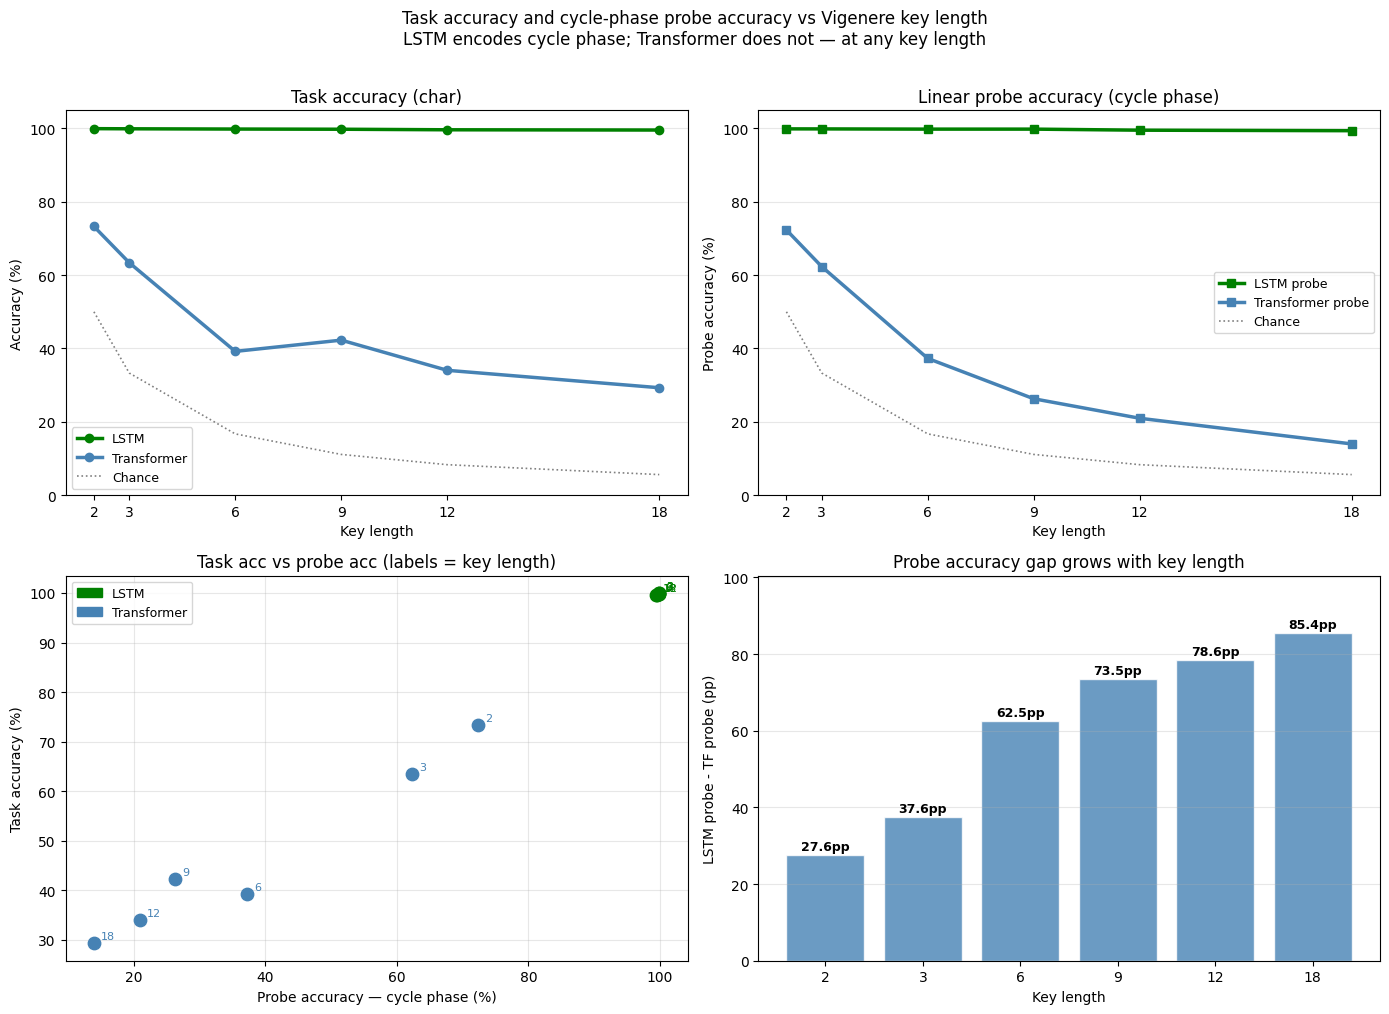

Saved: fig_p5_probing.pdf


In [9]:
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

kls         = KEY_LENGTHS
chance_vals = [all_results[str(kl)]["chance"]        for kl in kls]
lstm_task   = [all_results[str(kl)]["lstm_task_acc"] for kl in kls]
lstm_probe  = [all_results[str(kl)]["lstm_probe_acc"]for kl in kls]
tf_task     = [all_results[str(kl)]["tf_task_acc"]   for kl in kls]
tf_probe    = [all_results[str(kl)]["tf_probe_acc"]  for kl in kls]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Task accuracy and cycle-phase probe accuracy vs Vigenere key length\n"
    "LSTM encodes cycle phase; Transformer does not — at any key length",
    fontsize=12, y=1.01
)


ax = axes[0, 0]
ax.plot(kls, lstm_task,  color="green",     marker='o', linewidth=2.5,
        label="LSTM")
ax.plot(kls, tf_task,    color="steelblue", marker='o', linewidth=2.5,
        label="Transformer")
ax.plot(kls, chance_vals,color="gray",      linestyle=":", linewidth=1.2,
        label="Chance")
ax.set_title("Task accuracy (char)")
ax.set_xlabel("Key length")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(kls)
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)


ax = axes[0, 1]
ax.plot(kls, lstm_probe,  color="green",     marker='s', linewidth=2.5,
        label="LSTM probe")
ax.plot(kls, tf_probe,    color="steelblue", marker='s', linewidth=2.5,
        label="Transformer probe")
ax.plot(kls, chance_vals, color="gray",      linestyle=":", linewidth=1.2,
        label="Chance")
ax.set_title("Linear probe accuracy (cycle phase)")
ax.set_xlabel("Key length")
ax.set_ylabel("Probe accuracy (%)")
ax.set_xticks(kls)
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)


ax = axes[1, 0]
for kl in kls:
    r = all_results[str(kl)]
    ax.scatter(r['lstm_probe_acc'],  r['lstm_task_acc'],
               color="green",     s=80, zorder=3)
    ax.scatter(r['tf_probe_acc'],    r['tf_task_acc'],
               color="steelblue", s=80, zorder=3)
    ax.annotate(str(kl),
                (r['lstm_probe_acc'], r['lstm_task_acc']),
                textcoords="offset points", xytext=(5, 3), fontsize=8,
                color="green")
    ax.annotate(str(kl),
                (r['tf_probe_acc'], r['tf_task_acc']),
                textcoords="offset points", xytext=(5, 3), fontsize=8,
                color="steelblue")

ax.set_xlabel("Probe accuracy — cycle phase (%)")
ax.set_ylabel("Task accuracy (%)")
ax.set_title("Task acc vs probe acc (labels = key length)")
ax.legend(handles=[
    mpatches.Patch(color="green",     label="LSTM"),
    mpatches.Patch(color="steelblue", label="Transformer"),
], fontsize=9)
ax.grid(alpha=0.3)


ax = axes[1, 1]
probe_gaps = [lp - tp for lp, tp in zip(lstm_probe, tf_probe)]
bars = ax.bar([str(kl) for kl in kls], probe_gaps,
              color="steelblue", alpha=0.8, edgecolor="white")
for bar, g in zip(bars, probe_gaps):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{g:.1f}pp", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_xlabel("Key length")
ax.set_ylabel("LSTM probe - TF probe (pp)")
ax.set_title("Probe accuracy gap grows with key length")
ax.set_ylim(0, max(probe_gaps) + 15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_p5_probing.pdf"))
plt.show()
print("Saved: fig_p5_probing.pdf")

In [10]:
from google.colab import files as colab_files

for fname in ["p5_results.json", "fig_p5_probing.pdf"]:
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        colab_files.download(fpath)
        print(f"Downloaded: {fname}")
    else:
        print(f"Not found: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: p5_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig_p5_probing.pdf
